# Diffusion lab: train once, sample with DDPM and DDIM

**Diffusion model Part 1 • executed examples • CPU implementation**

Train a time-conditioned noise predictor, then compare stochastic DDPM sampling with deterministic DDIM sampling using **the same weights and initial noise**. Start with an eight-cluster distribution in two dimensions, then generate 8 × 8 handwritten digits.

The notebook includes saved numerical results and figures. To reproduce them, choose **Restart Kernel and Run All**. Training starts from random weights. No GPU, pretrained model, API key, or dataset download is required. The small networks are implemented in NumPy, including backpropagation and Adam, so every computation is visible.

Install the dependencies if needed:
```bash
python -m pip install numpy matplotlib scikit-learn jupyterlab
jupyter lab
```

The digit example adds a class label to the denoiser to make requested digits easy to compare. DDPM and DDIM are sampling procedures; neither requires a separately trained network in this lab. The images are deliberately small teaching examples, not MNIST at 28 × 28 or a production image generator.

**Workflow:** data → known Gaussian corruption → noise prediction training → DDPM → DDIM → measured comparisons → experiments.

In [1]:
import os
# Set before importing NumPy; threadpoolctl also handles an existing Jupyter kernel.
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
import time
import platform
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from threadpoolctl import threadpool_limits

_thread_limit = threadpool_limits(limits=1)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})
SEED = 42
T = 200
TOY_STEPS = 10_000       # Reduce for a quick code demonstration.
DIGIT_STEPS = 10_000     # Increase for a longer training experiment.
BATCH_SIZE = 256
print(f"Python {platform.python_version()} | NumPy {np.__version__} | "
      f"Matplotlib {matplotlib.__version__} | scikit-learn {sklearn.__version__}")
print(f"CPU, one BLAS thread; T={T}; training updates: toy={TOY_STEPS:,}, digits={DIGIT_STEPS:,}")

Python 3.12.14 | NumPy 2.3.5 | Matplotlib 3.10.8 | scikit-learn 1.8.0
CPU, one BLAS thread; T=200; training updates: toy=10,000, digits=10,000


## 1. Data with structure we can inspect

The synthetic distribution has eight equally likely Gaussian clusters. Its known centers let us check mode occupancy and distance to the target geometry. The digit data come from `sklearn.datasets.load_digits`, which bundles 8 × 8 grayscale images with integer intensities from 0 to 16. Rescale them to $[-1,1]$ and reserve a stratified 20% holdout.

The digit diffusion model trains only on the training split. A later nearest-neighbor classifier uses that same split and is checked on real holdout images before it is used as a diagnostic for generated samples. It is not a perceptual-quality benchmark.

Toy training points: 16,000
Digits: 1,437 train / 360 holdout; shape = 8 × 8


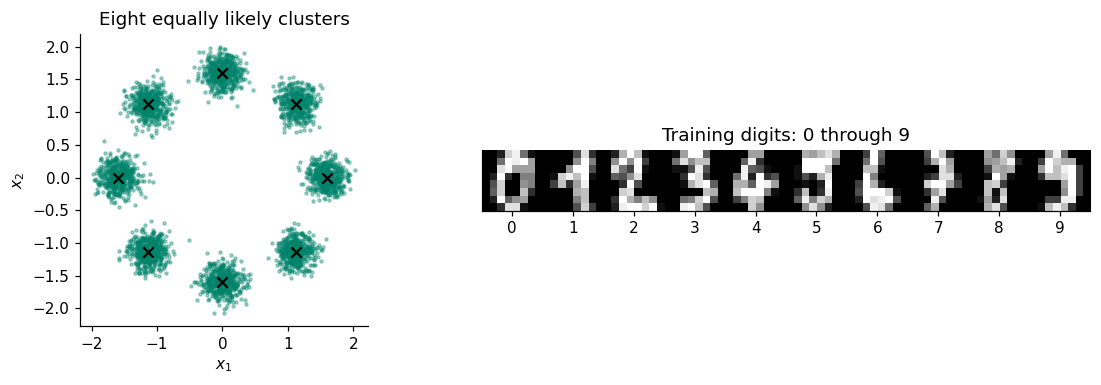

In [2]:
angles = np.arange(8) * 2 * np.pi / 8
centers = (1.6 * np.column_stack([np.cos(angles), np.sin(angles)])).astype(np.float32)
TOY_STD = 0.15

def draw_toy(n, seed):
    rng = np.random.default_rng(seed)
    modes = rng.integers(0, len(centers), size=n)
    return (centers[modes] + TOY_STD * rng.standard_normal((n, 2))).astype(np.float32)

toy_train = draw_toy(16_000, SEED)
toy_reference = draw_toy(2_048, SEED + 1)
digits = load_digits()
images = (digits.data / 8.0 - 1.0).astype(np.float32)
labels = digits.target.astype(np.int64)
train_idx, test_idx = train_test_split(
    np.arange(len(images)), test_size=0.2, random_state=SEED, stratify=labels)
x_train, y_train = images[train_idx], labels[train_idx]
x_test, y_test = images[test_idx], labels[test_idx]
print(f"Toy training points: {len(toy_train):,}")
print(f"Digits: {len(x_train):,} train / {len(x_test):,} holdout; shape = 8 × 8")

fig, axs = plt.subplots(1, 2, figsize=(11, 3.6))
axs[0].scatter(toy_train[::4, 0], toy_train[::4, 1], s=4, alpha=0.35, color="#00836b")
axs[0].scatter(centers[:, 0], centers[:, 1], s=45, marker="x", color="black")
axs[0].set(aspect="equal", title="Eight equally likely clusters", xlabel="$x_1$", ylabel="$x_2$")
examples = np.stack([x_train[np.flatnonzero(y_train == k)[0]].reshape(8, 8) for k in range(10)])
axs[1].imshow(np.concatenate(examples, axis=1), cmap="gray", vmin=-1, vmax=1,
              interpolation="nearest")
axs[1].set_title("Training digits: 0 through 9")
axs[1].set_xticks(np.arange(10) * 8 + 3.5, labels=np.arange(10))
axs[1].set_yticks([])
fig.tight_layout()
plt.show()

## 2. Forward diffusion and the time convention

Use **mathematical indices** $t=1,\ldots,T$ in the arrays. Index 0 is the clean endpoint:

$$\alpha_t=1-\beta_t,\qquad \bar\alpha_t=\prod_{s=1}^t\alpha_s,\qquad \bar\alpha_0=1.$$
$$x_t=\sqrt{\bar\alpha_t}\,x_0+\sqrt{1-\bar\alpha_t}\,\epsilon,
\qquad\epsilon\sim\mathcal N(0,I).$$

The short, linear schedule below is a teaching choice: its endpoint makes retained signal small with 200 steps. It is not the original 1,000-step DDPM schedule. `q_sample` jumps directly to a selected noise level; it does not simulate the preceding steps.

alpha_bar[T] = 0.000266; retained signal amplitude = 0.0163


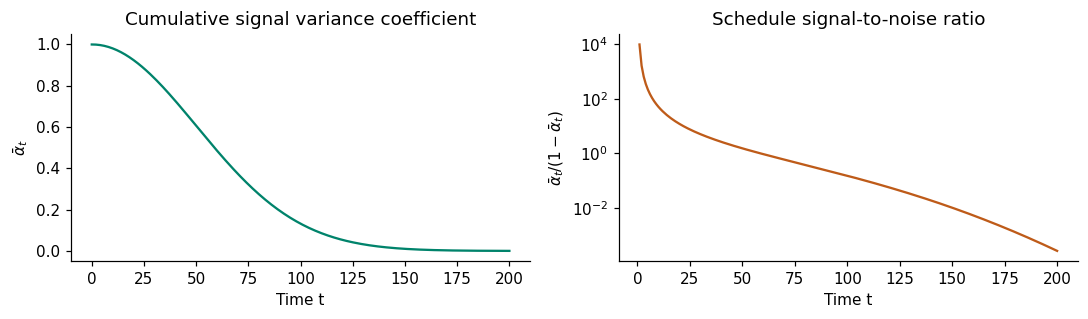

In [3]:
beta = np.concatenate([[0.0], np.linspace(1e-4, 0.08, T)])
alpha = 1.0 - beta
alpha_bar = np.cumprod(alpha)  # float64 coefficients reduce accumulated roundoff.

def q_sample(x0, t, noise):
    t = np.asarray(t, dtype=np.int64)
    a = alpha_bar[t][:, None]
    return (np.sqrt(a) * x0 + np.sqrt(1.0 - a) * noise).astype(np.float32)

assert alpha_bar[0] == 1.0
assert np.all(np.diff(alpha_bar) < 0)
print(f"alpha_bar[T] = {alpha_bar[-1]:.6f}; retained signal amplitude = {np.sqrt(alpha_bar[-1]):.4f}")
fig, axs = plt.subplots(1, 2, figsize=(10, 3))
axs[0].plot(np.arange(T+1), alpha_bar, color="#00836b")
axs[0].set(title="Cumulative signal variance coefficient", xlabel="Time t", ylabel=r"$\bar\alpha_t$")
axs[1].semilogy(np.arange(1, T+1), alpha_bar[1:] / (1-alpha_bar[1:]), color="#be5b19")
axs[1].set(title="Schedule signal-to-noise ratio", xlabel="Time t", ylabel=r"$\bar\alpha_t/(1-\bar\alpha_t)$")
fig.tight_layout()
plt.show()

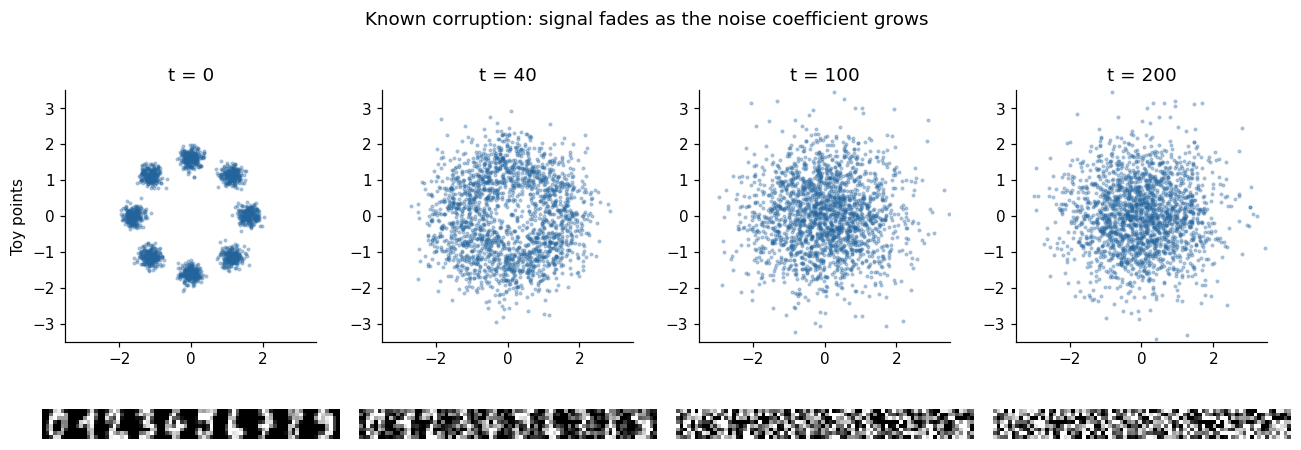

In [4]:
# Reuse one residual for visualization. Each panel has the correct conditional marginal,
# but this shared-noise display is not a sampled DDPM Markov trajectory.
rng = np.random.default_rng(SEED + 2)
show_times = [0, 40, 100, T]
toy_noise = rng.standard_normal(toy_reference.shape).astype(np.float32)
digit_row = examples.reshape(10, 64)
digit_noise = rng.standard_normal(digit_row.shape).astype(np.float32)
fig, axs = plt.subplots(2, len(show_times), figsize=(12, 5))
for j, t in enumerate(show_times):
    noisy_points = q_sample(toy_reference, np.full(len(toy_reference), t), toy_noise)
    axs[0, j].scatter(noisy_points[:, 0], noisy_points[:, 1], s=3, alpha=0.3, color="#24649d")
    axs[0, j].set(xlim=(-3.5, 3.5), ylim=(-3.5, 3.5), aspect="equal", title=f"t = {t}")
    noisy_digits = q_sample(digit_row, np.full(10, t), digit_noise)
    axs[1, j].imshow(np.concatenate(noisy_digits.reshape(10, 8, 8), axis=1),
                     cmap="gray", vmin=-1, vmax=1, interpolation="nearest")
    axs[1, j].axis("off")
axs[0, 0].set_ylabel("Toy points")
fig.suptitle("Known corruption: signal fades as the noise coefficient grows", y=1.01)
fig.tight_layout()
plt.show()

## 3. A small noise predictor, with its gradients exposed

The network takes the noisy vector, sinusoidal time features, and (for digits) a one-hot class label. Two hidden layers use SiLU, $z\,\mathrm{sigmoid}(z)$. The linear output predicts a noise vector of the same dimension as the input.

Training minimizes the **unweighted noise MSE**, not the complete negative ELBO. Adam updates the parameters; an exponential moving average (EMA) supplies the sampling weights. EMA is a numerical training choice used for both samplers. The class below contains the full forward pass, backpropagation, and optimizer rather than hiding them in a deep-learning framework.

In [5]:
def time_features(t):
    normalized_t = np.asarray(t)[:, None] / T
    frequencies = (2.0 ** np.arange(8))[None, :]
    phase = 2.0 * np.pi * normalized_t * frequencies
    return np.concatenate([np.sin(phase), np.cos(phase),
                           np.sqrt(alpha_bar[t])[:, None],
                           np.sqrt(1-alpha_bar[t])[:, None]], axis=1).astype(np.float32)

class NoiseMLP:
    def __init__(self, data_dim, hidden=128, n_classes=0, seed=SEED):
        self.n_classes = n_classes
        dims = [data_dim + 18 + n_classes, hidden, hidden, data_dim]
        rng = np.random.default_rng(seed)
        self.params = []
        for fan_in, fan_out in zip(dims[:-1], dims[1:]):
            W = rng.normal(0, np.sqrt(2/fan_in), (fan_in, fan_out)).astype(np.float32)
            self.params.extend([W, np.zeros(fan_out, dtype=np.float32)])
        self.params[-2] *= 0.05  # Start with a small noise prediction.
        self.m = [np.zeros_like(p) for p in self.params]
        self.v = [np.zeros_like(p) for p in self.params]
        self.ema = [p.copy() for p in self.params]
        self.update_count = 0
        self.inference_calls = 0

    def forward(self, x, t, classes=None, use_ema=False, cache=False):
        parts = [x, time_features(t)]
        if self.n_classes:
            if classes is None or len(classes) != len(x):
                raise ValueError("Supply one valid class label per image.")
            if np.any((classes < 0) | (classes >= self.n_classes)):
                raise ValueError("Class labels are out of range.")
            parts.append(np.eye(self.n_classes, dtype=np.float32)[classes])
        a = np.concatenate(parts, axis=1).astype(np.float32)
        params = self.ema if use_ema else self.params
        saved = []
        for i in range(0, len(params), 2):
            z = a @ params[i] + params[i+1]
            sigmoid = None
            if i < len(params)-2:
                sigmoid = 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))
                out = z * sigmoid
            else:
                out = z
            saved.append((a, z, sigmoid))
            a = out
        return (a, saved) if cache else a

    def loss_and_gradients(self, x, t, target_noise, classes=None):
        prediction, saved = self.forward(x, t, classes, cache=True)
        loss = np.mean((prediction-target_noise)**2)
        delta = 2.0 * (prediction-target_noise) / prediction.size
        gradients = [None] * len(self.params)
        for layer in range(len(saved)-1, -1, -1):
            a, z, sigmoid = saved[layer]
            if sigmoid is not None:
                delta = delta * (sigmoid + z*sigmoid*(1-sigmoid))
            i = 2*layer
            gradients[i] = a.T @ delta
            gradients[i+1] = delta.sum(axis=0)
            delta = delta @ self.params[i].T
        return float(loss), gradients

    def train_step(self, x, t, target_noise, classes=None, lr=1e-3):
        loss, gradients = self.loss_and_gradients(x, t, target_noise, classes)
        norm = np.sqrt(sum(np.sum(g*g) for g in gradients))
        scale = min(1.0, 1.0/(norm+1e-8))  # Global gradient norm cap.
        self.update_count += 1
        for i, (param, gradient) in enumerate(zip(self.params, gradients)):
            gradient = gradient * scale
            self.m[i] = 0.9*self.m[i] + 0.1*gradient
            self.v[i] = 0.999*self.v[i] + 0.001*gradient**2
            m_hat = self.m[i] / (1-0.9**self.update_count)
            v_hat = self.v[i] / (1-0.999**self.update_count)
            param -= lr*m_hat/(np.sqrt(v_hat)+1e-8)
            self.ema[i] = 0.995*self.ema[i] + 0.005*param
        return loss

    def predict(self, x, t, classes=None):
        self.inference_calls += 1
        return self.forward(x, t, classes, use_ema=True)

print("Network: two SiLU hidden layers; 18 time features; linear noise output.")

Network: two SiLU hidden layers; 18 time features; linear noise output.


### Numerical checks before training

A finite-difference check compares several backpropagated derivatives with changes in the actual MSE. A Monte Carlo check tests the forward marginal's mean and variance. These catch a different class of mistake from merely verifying array shapes.

In [6]:
rng = np.random.default_rng(7)
small = NoiseMLP(3, hidden=12, seed=7)
x = rng.standard_normal((5, 3)).astype(np.float32)
t = np.array([1, 25, 50, 100, 200])
eps = rng.standard_normal(x.shape).astype(np.float32)
loss, gradients = small.loss_and_gradients(x, t, eps)
errors = []
for p_idx, index in [(0, (0, 0)), (2, (1, 2)), (4, (3, 0)), (5, (1,))]:
    original = float(small.params[p_idx][index])
    h = 1e-3
    small.params[p_idx][index] = original+h
    plus = small.loss_and_gradients(x, t, eps)[0]
    small.params[p_idx][index] = original-h
    minus = small.loss_and_gradients(x, t, eps)[0]
    small.params[p_idx][index] = original
    numerical = (plus-minus)/(2*h)
    analytic = float(gradients[p_idx][index])
    errors.append(abs(numerical-analytic))
assert max(errors) < 2e-4, errors

x0 = np.repeat([[0.3, -0.4]], 40_000, axis=0).astype(np.float32)
forward_noise = rng.standard_normal(x0.shape).astype(np.float32)
xt = q_sample(x0, np.full(len(x0), 100), forward_noise)
assert np.allclose(xt.mean(0), np.sqrt(alpha_bar[100])*x0[0], atol=0.02)
assert np.allclose(xt.var(0), 1-alpha_bar[100], atol=0.03)
assert np.array_equal(q_sample(x0[:2], np.zeros(2, dtype=int), forward_noise[:2]), x0[:2])
print(f"Gradient check passed: maximum absolute error {max(errors):.2e}")
print("Forward mean, variance, and clean-endpoint checks passed.")

Gradient check passed: maximum absolute error 6.60e-05
Forward mean, variance, and clean-endpoint checks passed.


## 4. Train the two denoisers from random weights

For each update: choose clean data, sample $t$ uniformly, sample $\epsilon$, construct $x_t$, predict $\epsilon$, and minimize its MSE. The digit model receives the requested class as an extra input. No sampling algorithm is used inside the training loop.

The learning rate decreases from approximately $10^{-3}$ to $2.5\times10^{-4}$. Printed losses are averages over the last 200 updates. Runtime is measured on the executing machine; it will vary with hardware and libraries.

In [7]:
def train_model(model, data, classes=None, updates=10_000, seed=SEED):
    rng = np.random.default_rng(seed)
    history = []
    started = time.perf_counter()
    for step in range(1, updates+1):
        indices = rng.integers(0, len(data), size=BATCH_SIZE)
        clean = data[indices]
        times = rng.integers(1, T+1, size=len(indices))
        noise = rng.standard_normal(clean.shape).astype(np.float32)
        noisy = q_sample(clean, times, noise)
        batch_classes = None if classes is None else classes[indices]
        lr = 1e-3 * (0.25+0.75*(1-step/updates))
        history.append(model.train_step(noisy, times, noise, batch_classes, lr))
        if step % 2_000 == 0 or step == updates:
            print(f"  {step:>6,} updates | recent MSE {np.mean(history[-200:]):.4f} | "
                  f"elapsed {time.perf_counter()-started:.1f} s")
    return np.asarray(history), time.perf_counter()-started

toy_model = NoiseMLP(2, hidden=128, seed=SEED)
print("Training the unconditional 2D model")
toy_loss, toy_training_seconds = train_model(
    toy_model, toy_train, updates=TOY_STEPS, seed=SEED)

digit_model = NoiseMLP(64, hidden=256, n_classes=10, seed=SEED)
print("Training the class-conditioned digit model")
digit_loss, digit_training_seconds = train_model(
    digit_model, x_train, y_train, updates=DIGIT_STEPS, seed=SEED+1)

Training the unconditional 2D model
   2,000 updates | recent MSE 0.2834 | elapsed 2.7 s
   4,000 updates | recent MSE 0.2729 | elapsed 5.3 s
   6,000 updates | recent MSE 0.2707 | elapsed 7.9 s
   8,000 updates | recent MSE 0.2653 | elapsed 10.6 s
  10,000 updates | recent MSE 0.2633 | elapsed 13.5 s
Training the class-conditioned digit model
   2,000 updates | recent MSE 0.1571 | elapsed 9.3 s
   4,000 updates | recent MSE 0.1424 | elapsed 17.6 s
   6,000 updates | recent MSE 0.1346 | elapsed 25.3 s
   8,000 updates | recent MSE 0.1296 | elapsed 33.0 s
  10,000 updates | recent MSE 0.1257 | elapsed 41.1 s


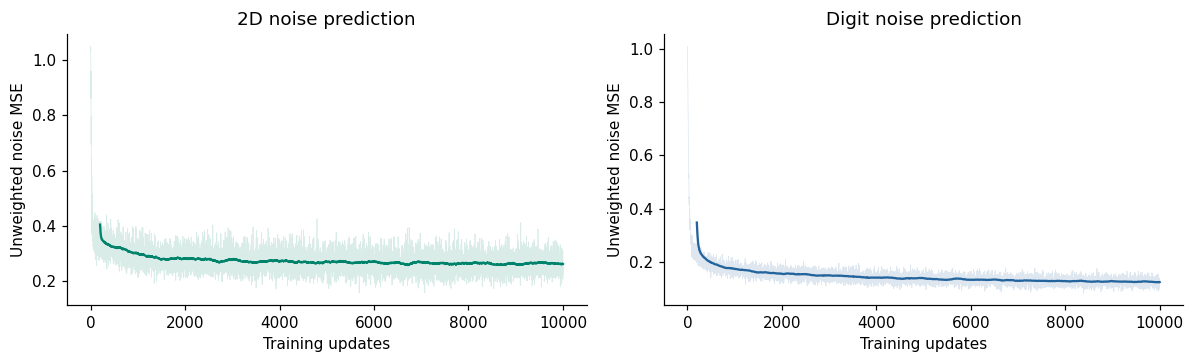

Fresh toy noise MSE:   model 0.2654 / predict-zero baseline 1.0012
Holdout digit MSE:     model 0.1389 / predict-zero baseline 1.0031


In [8]:
def smooth(values, window=200):
    return np.convolve(values, np.ones(window)/window, mode="valid")

fig, axs = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, values, title, color in zip(
        axs, [toy_loss, digit_loss], ["2D noise prediction", "Digit noise prediction"],
        ["#00836b", "#24649d"]):
    ax.plot(np.arange(1, len(values)+1), values, alpha=0.15, color=color, linewidth=0.5)
    smoothed = smooth(values, min(200, len(values)))
    ax.plot(np.arange(len(values)-len(smoothed)+1, len(values)+1), smoothed, color=color)
    ax.set(title=title, xlabel="Training updates", ylabel="Unweighted noise MSE")
fig.tight_layout()
plt.show()

# Fixed, separate validation perturbations: no optimizer updates here.
def validation_mse(model, clean, classes=None, seed=123):
    rng = np.random.default_rng(seed)
    times = rng.integers(1, T+1, size=len(clean))
    noise = rng.standard_normal(clean.shape).astype(np.float32)
    pred = model.predict(q_sample(clean, times, noise), times, classes)
    return float(np.mean((pred-noise)**2)), float(np.mean(noise**2))

toy_val, toy_zero = validation_mse(toy_model, toy_reference)
digit_val, digit_zero = validation_mse(digit_model, x_test, y_test)
print(f"Fresh toy noise MSE:   model {toy_val:.4f} / predict-zero baseline {toy_zero:.4f}")
print(f"Holdout digit MSE:     model {digit_val:.4f} / predict-zero baseline {digit_zero:.4f}")
assert toy_val < toy_zero and digit_val < digit_zero

## 5. DDPM: stochastic reverse sampling

At each neighboring time step, predict noise and obtain a clean estimate:
$$\hat x_0=\frac{x_t-\sqrt{1-\bar\alpha_t}\,\epsilon_\theta(x_t,t)}{\sqrt{\bar\alpha_t}}.$$
Use the Gaussian posterior coefficients to form the reverse mean and sample with variance $\tilde\beta_t$. Set fresh noise to zero at the clean endpoint. This is the fixed-posterior-variance DDPM choice.

For digits only, clip $\hat x_0$ to the training range $[-1,1]$. This is a sampling heuristic, not part of the unweighted training loss. Both image samplers use it; the 2D experiment does not clip predictions.

In [9]:
def estimate_clean(model, x, t, classes=None, clip=None):
    times = np.full(len(x), t, dtype=np.int64)
    predicted_noise = model.predict(x, times, classes)
    clean = (x-np.sqrt(1-alpha_bar[t])*predicted_noise)/np.sqrt(alpha_bar[t])
    if clip is not None:
        clean = np.clip(clean, -clip, clip)
    return clean

def sample_ddpm(model, initial_noise, classes=None, seed=0, clip=None):
    rng = np.random.default_rng(seed)
    x = np.asarray(initial_noise, dtype=np.float32).copy()
    snapshots = {T: x.copy()}
    before = model.inference_calls
    for t in range(T, 0, -1):
        a_t, a_prev = alpha_bar[t], alpha_bar[t-1]
        clean = estimate_clean(model, x, t, classes, clip)
        coefficient_clean = np.sqrt(a_prev)*beta[t]/(1-a_t)
        coefficient_noisy = np.sqrt(alpha[t])*(1-a_prev)/(1-a_t)
        mean = coefficient_clean*clean + coefficient_noisy*x
        variance = beta[t]*(1-a_prev)/(1-a_t)
        if t > 1:
            fresh_noise = rng.standard_normal(x.shape).astype(np.float32)
            x = mean + np.sqrt(variance)*fresh_noise
        else:
            x = mean  # No fresh noise at t=1.
        x = x.astype(np.float32)
        if t-1 in {160, 120, 80, 40, 20, 5, 0}:
            snapshots[t-1] = x.copy()
    return x, snapshots, model.inference_calls-before

## 6. DDIM: a selected time grid and controlled stochasticity

For a jump from $t$ to an earlier selected index $s$, use
$$\sigma_{t\to s}=\eta\sqrt{\frac{1-\bar\alpha_s}{1-\bar\alpha_t}
             \left(1-\frac{\bar\alpha_t}{\bar\alpha_s}\right)},$$
$$x_s=\sqrt{\bar\alpha_s}\,\hat x_0+
       \sqrt{1-\bar\alpha_s-\sigma_{t\to s}^2}\,\hat\epsilon+
       \sigma_{t\to s}z.$$

`eta=0` gives deterministic DDIM for a fixed initial state. `eta=1` on the full neighboring grid matches the posterior-variance DDPM construction used above, up to floating-point roundoff. This equivalence does not apply to every possible DDPM variance choice.

After clipping a digit clean estimate, recompute the residual $\hat\epsilon$ so the clean estimate and residual still reconstruct the current state. The code uses original trained time indices, not the number of iterations remaining.

In [10]:
def selected_times(steps):
    if not isinstance(steps, (int, np.integer)) or not 1 <= steps <= T:
        raise ValueError(f"steps must be an integer between 1 and {T}")
    times = np.rint(np.linspace(T, 1, steps)).astype(np.int64)
    assert len(np.unique(times)) == steps
    return times

def sample_ddim(model, initial_noise, steps=20, eta=0.0,
                classes=None, seed=0, clip=None):
    if not 0 <= eta <= 1:
        raise ValueError("This demonstration supports eta in [0,1].")
    rng = np.random.default_rng(seed)
    x = np.asarray(initial_noise, dtype=np.float32).copy()
    times = selected_times(steps)
    snapshots = {T: x.copy()}
    before = model.inference_calls
    for i, t in enumerate(times):
        s = times[i+1] if i+1 < len(times) else 0
        a_t, a_s = alpha_bar[t], alpha_bar[s]
        clean = estimate_clean(model, x, t, classes, clip)
        residual = (x-np.sqrt(a_t)*clean)/np.sqrt(1-a_t)
        sigma = eta*np.sqrt(max(0.0, (1-a_s)/(1-a_t)*(1-a_t/a_s)))
        direction = np.sqrt(max(0.0, 1-a_s-sigma**2))*residual
        x = np.sqrt(a_s)*clean + direction
        if sigma > 0:
            x = x + sigma*rng.standard_normal(x.shape).astype(np.float32)
        x = x.astype(np.float32)
        snapshots[int(s)] = x.copy()
    return x, snapshots, model.inference_calls-before

print("DDIM 20-step trained-time grid:", selected_times(20))

DDIM 20-step trained-time grid: [200 190 179 169 158 148 137 127 116 106  95  85  74  64  53  43  32  22
  11   1]


### Check deterministic behavior and the matched stochastic endpoint

Hold initial noise fixed. Changing the RNG seed must not change deterministic DDIM. It should change DDPM, because DDPM draws new reverse-step noise. Also compare full-grid `eta=1` DDIM with the specific DDPM implementation above, using the same random stream.

In [11]:
z_check = np.random.default_rng(101).standard_normal((32, 2)).astype(np.float32)
a, _, n_a = sample_ddim(toy_model, z_check, steps=20, eta=0, seed=1)
b, _, n_b = sample_ddim(toy_model, z_check, steps=20, eta=0, seed=999)
c, _, n_c = sample_ddpm(toy_model, z_check, seed=1)
d, _, _ = sample_ddpm(toy_model, z_check, seed=999)
e, _, n_e = sample_ddim(toy_model, z_check, steps=T, eta=1, seed=1)
assert np.array_equal(a, b)
assert not np.allclose(c, d)
assert n_a == 20 and n_b == 20 and n_c == T and n_e == T
assert np.allclose(c, e, atol=2e-4, rtol=2e-4), np.max(np.abs(c-e))
print(f"DDIM eta=0: max difference after changing RNG seed = {np.max(np.abs(a-b)):.1f}")
print(f"DDPM: MSE after changing reverse RNG seed = {np.mean((c-d)**2):.4f}")
print(f"DDPM vs full-grid eta=1 DDIM: max difference = {np.max(np.abs(c-e)):.2e}")

DDIM eta=0: max difference after changing RNG seed = 0.0
DDPM: MSE after changing reverse RNG seed = 2.6051
DDPM vs full-grid eta=1 DDIM: max difference = 0.00e+00


## 7. Generate 2D samples with the same starting noise

Compare DDPM with 200 evaluations against DDIM with 20 and 10 evaluations. The parameters and initial Gaussian vectors are identical across methods. Individual outputs need not match: the methods define different paths and DDPM adds fresh noise.

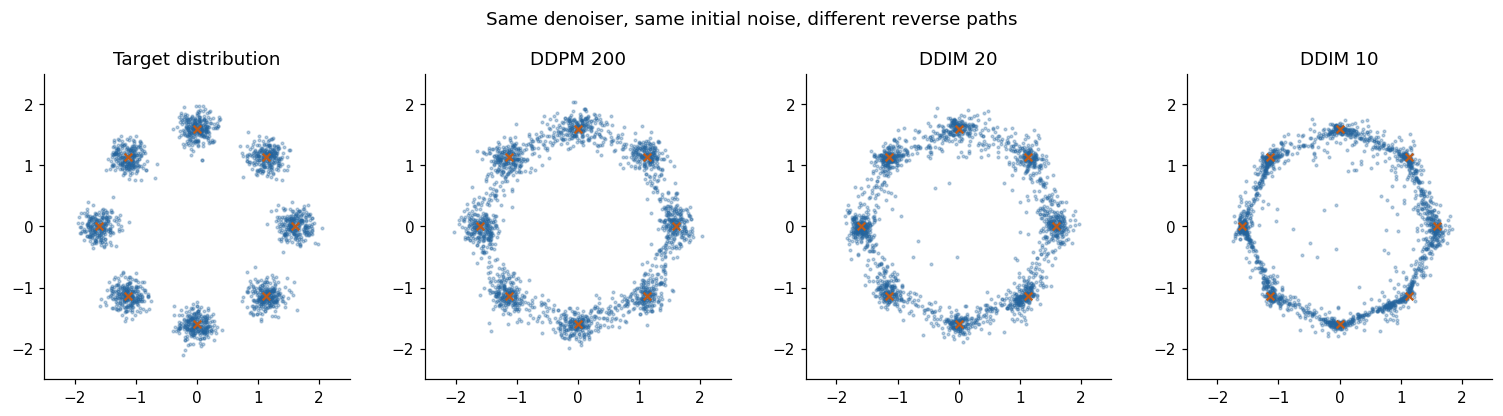

In [12]:
z_toy = np.random.default_rng(202).standard_normal((2_048, 2)).astype(np.float32)
toy_results = {}
toy_counts = {}
for name, steps in [("DDPM 200", T), ("DDIM 20", 20), ("DDIM 10", 10)]:
    if name.startswith("DDPM"):
        generated, snapshots, calls = sample_ddpm(toy_model, z_toy, seed=303)
    else:
        generated, snapshots, calls = sample_ddim(toy_model, z_toy, steps=steps)
    assert np.all(np.isfinite(generated))
    toy_results[name], toy_counts[name] = generated, calls

fig, axs = plt.subplots(1, 4, figsize=(14, 3.5))
bound = max(2.4, max(float(np.max(np.abs(v))) for v in toy_results.values())) + 0.1
for ax, (name, points) in zip(axs, [("Target distribution", toy_reference), *toy_results.items()]):
    ax.scatter(points[:, 0], points[:, 1], s=3, alpha=0.3, color="#24649d")
    ax.scatter(centers[:, 0], centers[:, 1], s=25, marker="x", color="#be5b19")
    ax.set(title=name, xlim=(-bound, bound), ylim=(-bound, bound), aspect="equal")
fig.suptitle("Same denoiser, same initial noise, different reverse paths", y=1.02)
fig.tight_layout()
plt.show()

### Distribution diagnostics, not a single visual judgment

**Sliced Wasserstein-1** averages the distance between sorted projections of two equally sized point clouds along 64 fixed random directions. Smaller is better for this sample-based comparison. It is not an image FID score.

Also assign each sample to its nearest known cluster center. Mode frequencies reveal imbalance, while the fraction within three cluster standard deviations checks whether points concentrate around the intended geometry. A fresh target-versus-target comparison gives a finite-sample reference level. These diagnostics use one trained model and one sample batch.

Method             Calls    Sliced W1   Within 3 std
Target vs target       0       0.0408         99.1%
DDPM 200             200       0.0558         88.3%
DDIM 20               20       0.0767         87.5%
DDIM 10               10       0.0952         85.0%


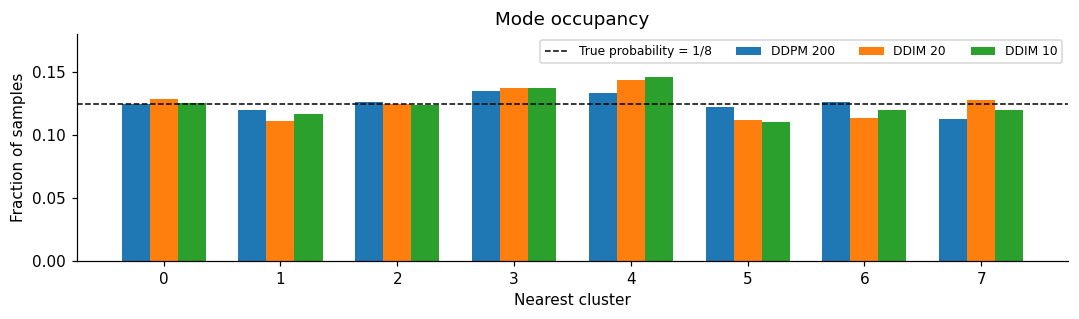

In [13]:
def sliced_w1(a, b, projections=64, seed=0):
    if len(a) != len(b):
        raise ValueError("This simple implementation requires equal sample counts.")
    rng = np.random.default_rng(seed)
    directions = rng.standard_normal((a.shape[1], projections))
    directions /= np.linalg.norm(directions, axis=0, keepdims=True)
    return float(np.mean(np.abs(np.sort(a@directions, axis=0)-np.sort(b@directions, axis=0))))

def mode_diagnostics(points):
    distances = np.linalg.norm(points[:, None, :]-centers[None, :, :], axis=2)
    assignment = distances.argmin(axis=1)
    fractions = np.bincount(assignment, minlength=8)/len(points)
    near = float(np.mean(distances.min(axis=1) < 3*TOY_STD))
    return fractions, near

print(f"{'Method':<17} {'Calls':>6} {'Sliced W1':>12} {'Within 3 std':>14}")
for name, points in [("Target vs target", draw_toy(2_048, 919)), *toy_results.items()]:
    _, near = mode_diagnostics(points)
    calls = toy_counts.get(name, 0)
    print(f"{name:<17} {calls:>6} {sliced_w1(points, toy_reference):>12.4f} {near:>13.1%}")

fig, ax = plt.subplots(figsize=(10, 3))
for i, (name, points) in enumerate(toy_results.items()):
    occupancy, _ = mode_diagnostics(points)
    ax.bar(np.arange(8)+(i-1)*0.24, occupancy, width=0.24, label=name)
ax.axhline(1/8, color="black", linestyle="--", linewidth=1, label="True probability = 1/8")
ax.set(xlabel="Nearest cluster", ylabel="Fraction of samples", xticks=np.arange(8), title="Mode occupancy")
ax.set_ylim(0, 0.18)
ax.legend(ncol=4, fontsize=8)
fig.tight_layout()
plt.show()

## 8. Generate handwritten digits

Supply labels 0 through 9 and reuse the same 200 initial Gaussian image vectors across samplers. The gallery displays the first three samples for each requested class. The plotted intensity range is fixed at $[-1,1]$, with nearest-neighbor display so the actual 8 × 8 resolution remains visible.

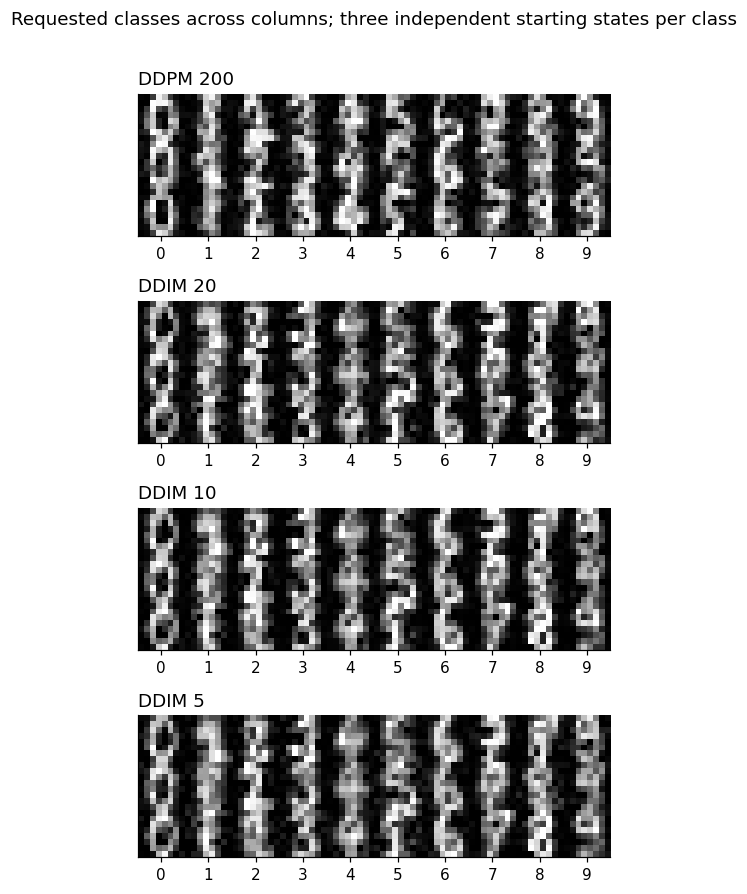

In [14]:
requested_labels = np.tile(np.arange(10), 20)
z_digits = np.random.default_rng(404).standard_normal((len(requested_labels), 64)).astype(np.float32)
digit_results = {}
for name, steps in [("DDPM 200", T), ("DDIM 20", 20), ("DDIM 10", 10), ("DDIM 5", 5)]:
    if name.startswith("DDPM"):
        generated, snapshots, calls = sample_ddpm(
            digit_model, z_digits, requested_labels, seed=505, clip=1.0)
    else:
        generated, snapshots, calls = sample_ddim(
            digit_model, z_digits, steps=steps, classes=requested_labels, clip=1.0)
    assert np.all(np.isfinite(generated)) and calls == steps
    digit_results[name] = generated

fig, axs = plt.subplots(4, 1, figsize=(12, 8))
for ax, (name, generated) in zip(axs, digit_results.items()):
    rows = [np.concatenate(generated[j*10:(j+1)*10].reshape(10, 8, 8), axis=1) for j in range(3)]
    ax.imshow(np.concatenate(rows, axis=0), cmap="gray", vmin=-1, vmax=1, interpolation="nearest")
    ax.set_yticks([])
    ax.set_xticks(np.arange(10)*8+3.5, labels=np.arange(10))
    ax.set_title(name, loc="left")
fig.suptitle("Requested classes across columns; three independent starting states per class", y=1.01)
fig.tight_layout()
plt.show()

### Requested-class agreement and a nearest-training-image inspection

A 3-nearest-neighbor classifier is a simple diagnostic: does a generated image resemble real examples of its requested digit? Its agreement can be high even when an image is blurry or lacks diversity. Report its real holdout accuracy to make the proxy's own limitations visible.

The nearest-image gallery compares generated digits with their nearest training images in pixel Euclidean distance. It helps inspect similarities; neither a close match nor a positive distance alone establishes or rules out memorization.

Classifier accuracy on real holdout digits: 98.6%
Generated diagnostic sample count: 200 (20 per requested class)
Sampler           Requested-class agreement
DDPM 200                             96.5%
DDIM 20                              86.5%
DDIM 10                              88.5%
DDIM 5                               89.5%


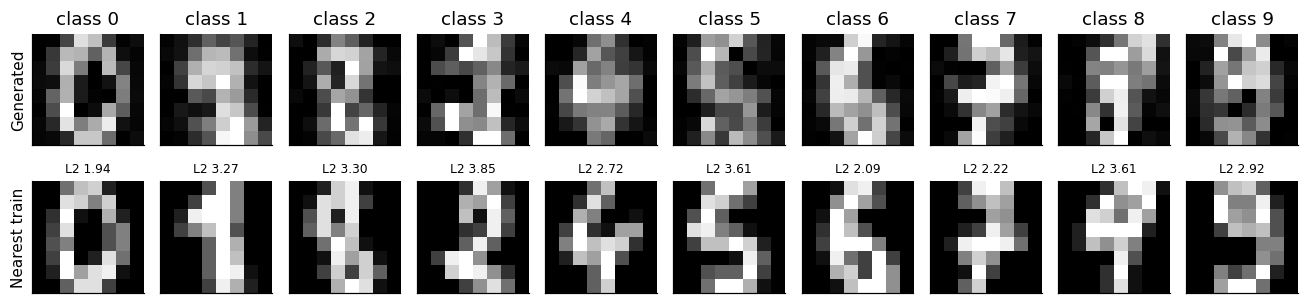

In [15]:
classifier = KNeighborsClassifier(n_neighbors=3)
classifier.fit(x_train, y_train)
print(f"Classifier accuracy on real holdout digits: {classifier.score(x_test, y_test):.1%}")
print(f"Generated diagnostic sample count: {len(requested_labels)} (20 per requested class)")
print(f"{'Sampler':<14} {'Requested-class agreement':>28}")
for name, generated in digit_results.items():
    agreement = np.mean(classifier.predict(generated) == requested_labels)
    print(f"{name:<14} {agreement:>27.1%}")

selected = digit_results["DDIM 20"][:10]
squared_distances = ((selected[:, None, :]-x_train[None, :, :])**2).sum(axis=2)
nearest = squared_distances.argmin(axis=1)
fig, axs = plt.subplots(2, 10, figsize=(12, 3))
for k in range(10):
    axs[0, k].imshow(selected[k].reshape(8, 8), cmap="gray", vmin=-1, vmax=1, interpolation="nearest")
    axs[1, k].imshow(x_train[nearest[k]].reshape(8, 8), cmap="gray", vmin=-1, vmax=1, interpolation="nearest")
    axs[0, k].set_title(f"class {k}")
    axs[1, k].set_title(f"L2 {np.sqrt(squared_distances[k, nearest[k]]):.2f}", fontsize=8)
    for ax in axs[:, k]:
        ax.set_xticks([]); ax.set_yticks([])
axs[0, 0].set_ylabel("Generated")
axs[1, 0].set_ylabel("Nearest train")
fig.tight_layout()
plt.show()

## 9. Inspect denoising trajectories

Show the same initial noise image for a requested digit 3. DDPM and DDIM snapshots use their actual time labels. DDIM does not necessarily visit the same intermediate times as DDPM, so each panel states the time actually reached. The grayscale display clips only the visualization of noisy states to the fixed plotting range.

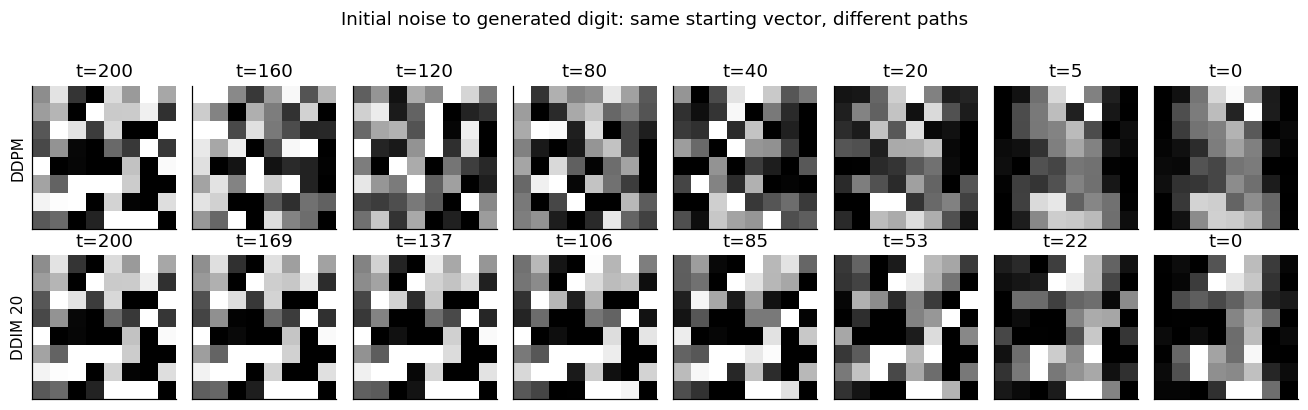

In [16]:
trace_label = np.array([3])
trace_noise = z_digits[3:4]
_, ddpm_trace, _ = sample_ddpm(digit_model, trace_noise, trace_label, seed=606, clip=1.0)
_, ddim_trace, _ = sample_ddim(digit_model, trace_noise, steps=20, classes=trace_label, clip=1.0)
fig, axs = plt.subplots(2, 8, figsize=(12, 3.7))
for row, (name, trace) in enumerate([("DDPM", ddpm_trace), ("DDIM 20", ddim_trace)]):
    available = sorted(trace, reverse=True)
    picks = np.rint(np.linspace(0, len(available)-1, 8)).astype(int)
    for col, index in enumerate(picks):
        t = available[index]
        axs[row, col].imshow(trace[t][0].reshape(8, 8), cmap="gray", vmin=-1, vmax=1,
                              interpolation="nearest")
        axs[row, col].set_title(f"t={t}")
        axs[row, col].set_xticks([]); axs[row, col].set_yticks([])
    axs[row, 0].set_ylabel(name)
fig.suptitle("Initial noise to generated digit: same starting vector, different paths", y=1.02)
fig.tight_layout()
plt.show()

## 10. Measure sampling cost on this machine

Benchmark the digit model with a fixed batch of 100 images. Each sampler gets a warm-up and three measured runs. Report the median elapsed time and actual batch-level network evaluations. The factor $T/S$ compares evaluation counts; it is not a guaranteed wall-clock speedup or an assertion of equal quality.

Sampler         Calls   Median seconds   Measured speedup
DDPM 200          200           0.1402              1.00x
DDIM 50            50           0.0314              4.47x
DDIM 20            20           0.0112             12.52x
DDIM 10            10           0.0063             22.28x
DDIM 5              5           0.0034             41.44x


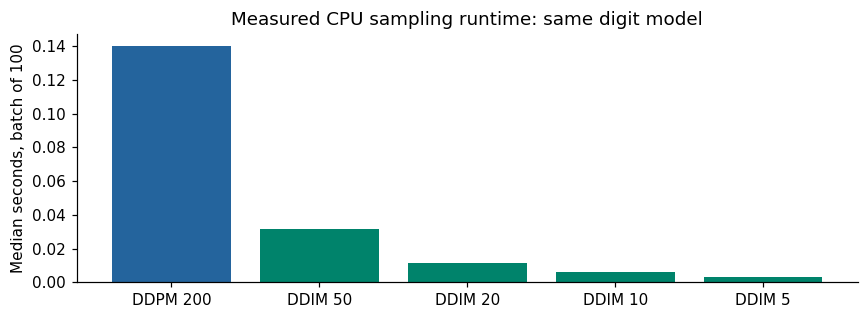

In [17]:
benchmark_noise = z_digits[:100]
benchmark_labels = requested_labels[:100]

def measured_sampling(name, steps, repeats=3):
    def run():
        if name == "DDPM":
            return sample_ddpm(digit_model, benchmark_noise, benchmark_labels, seed=707, clip=1.0)
        return sample_ddim(digit_model, benchmark_noise, steps=steps,
                           classes=benchmark_labels, clip=1.0)
    run()  # Warm-up.
    timings = []
    for _ in range(repeats):
        started = time.perf_counter()
        _, _, calls = run()
        timings.append(time.perf_counter()-started)
    return float(np.median(timings)), calls

runtime_rows = []
for name, steps in [("DDPM", T), ("DDIM", 50), ("DDIM", 20), ("DDIM", 10), ("DDIM", 5)]:
    seconds, calls = measured_sampling(name, steps)
    runtime_rows.append((f"{name} {steps}", seconds, calls))
base_seconds = runtime_rows[0][1]
print(f"{'Sampler':<14} {'Calls':>6} {'Median seconds':>16} {'Measured speedup':>18}")
for name, seconds, calls in runtime_rows:
    print(f"{name:<14} {calls:>6} {seconds:>16.4f} {base_seconds/seconds:>17.2f}x")
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar([r[0] for r in runtime_rows], [r[1] for r in runtime_rows],
       color=["#24649d"]+["#00836b"]*4)
ax.set(ylabel="Median seconds, batch of 100", title="Measured CPU sampling runtime: same digit model")
fig.tight_layout()
plt.show()

## 11. Hands-on experiments

Change one parameter at a time. The next cells are runnable examples, not unfinished placeholders.

1. **Step budget:** compare 5, 10, 20, and 50 DDIM steps. Which diagnostics change fastest as evaluations decrease?
2. **Stochasticity:** change `experiment_eta` between 0 and 1 while holding initial noise fixed. Which source of randomness changes the output?
3. **Training budget:** reduce `TOY_STEPS` or `DIGIT_STEPS`, restart the kernel, and rerun. Does lower training MSE always predict better-looking samples?
4. **Noise schedule:** alter the beta endpoint and inspect `alpha_bar[T]`. If much clean signal remains at T, why is a standard normal sampling prior less appropriate?
5. **Labels:** keep an initial image noise vector fixed and change the requested digit. The label conditions the model; it does not alter the sampler's equations.

  DDIM steps    Sliced W1   Within 3 std
           5       0.2365         57.3%
          10       0.0952         85.0%
          20       0.0767         87.5%
          50       0.0640         89.5%


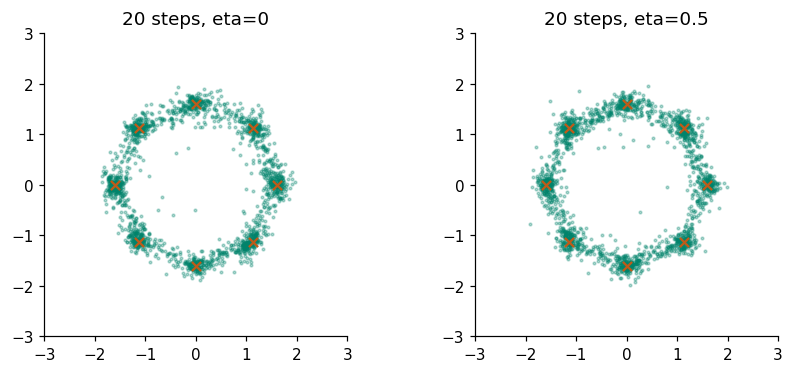

In [18]:
print(f"{'DDIM steps':>12} {'Sliced W1':>12} {'Within 3 std':>14}")
for steps in [5, 10, 20, 50]:
    points, _, calls = sample_ddim(toy_model, z_toy, steps=steps, eta=0)
    _, near = mode_diagnostics(points)
    print(f"{calls:>12} {sliced_w1(points, toy_reference):>12.4f} {near:>13.1%}")

experiment_eta = 0.5  # Try 0.0 or 1.0, then rerun this cell.
eta_zero, _, _ = sample_ddim(toy_model, z_toy, steps=20, eta=0, seed=808)
eta_changed, _, _ = sample_ddim(toy_model, z_toy, steps=20, eta=experiment_eta, seed=808)
fig, axs = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, points, eta in zip(axs, [eta_zero, eta_changed], [0, experiment_eta]):
    ax.scatter(points[:, 0], points[:, 1], s=3, alpha=0.3, color="#00836b")
    ax.scatter(centers[:, 0], centers[:, 1], marker="x", color="#be5b19")
    ax.set(title=f"20 steps, eta={eta}", aspect="equal", xlim=(-3, 3), ylim=(-3, 3))
fig.tight_layout()
plt.show()

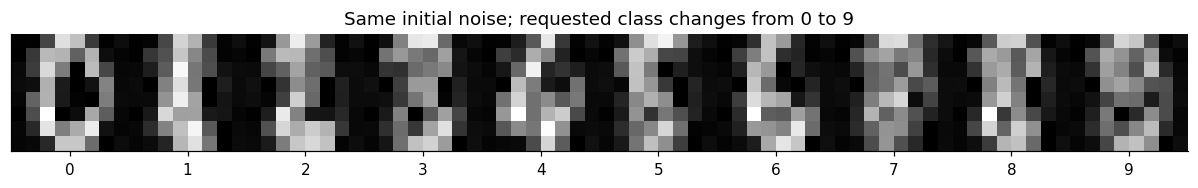

In [19]:
# Same initial Gaussian vector, ten different requested classes.
repeated_initial_state = np.repeat(z_digits[0:1], 10, axis=0)
label_sweep, _, _ = sample_ddim(digit_model, repeated_initial_state, steps=20,
                               classes=np.arange(10), clip=1.0)
fig, ax = plt.subplots(figsize=(11, 1.9))
ax.imshow(np.concatenate(label_sweep.reshape(10, 8, 8), axis=1), cmap="gray", vmin=-1, vmax=1,
          interpolation="nearest")
ax.set_xticks(np.arange(10)*8+3.5, labels=np.arange(10)); ax.set_yticks([])
ax.set_title("Same initial noise; requested class changes from 0 to 9")
fig.tight_layout()
plt.show()

## Reading the results

- **Training loss** measures noise regression on the selected schedule. The validation cell checks new perturbations and held-out real digits, but loss alone does not measure generated diversity.
- **Mode occupancy and sliced W1** describe this known two-dimensional example. Their target-versus-target row exposes finite-sample discrepancy.
- **Digit class agreement** is a nearest-neighbor proxy. Inspect the galleries alongside it: recognizable labels can coexist with blurred strokes or limited variation.
- **Runtime** compares the same model and batch on one machine. A smaller step budget reduces calls but can change the resulting distribution.
- **Deterministic DDIM** means no fresh reverse-step randomness when `eta=0`. Different initial Gaussian samples still produce different outputs.

The short schedule, small MLPs, image clipping, conditional digit labels, and single training seed are deliberate teaching choices. These experiments do not establish a general ranking of DDPM and DDIM or production image quality.

### References and notation

The diffusion equations follow the lecture's notation: one-step $\alpha_t$ and cumulative $\bar\alpha_t$. The DDIM paper uses $\alpha_t$ for the cumulative quantity; keep that distinction in mind when comparing the paper with this code.

- Jonathan Ho, Ajay Jain, and Pieter Abbeel. **Denoising Diffusion Probabilistic Models** (2020), https://arxiv.org/abs/2006.11239.
- Jiaming Song, Chenlin Meng, and Stefano Ermon. **Denoising Diffusion Implicit Models** (2020, ICLR 2021), https://arxiv.org/abs/2010.02502.
- scikit-learn `load_digits` documentation and dataset description: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html.

The figures and numerical outputs in this notebook come from the executed code above. No displayed result is an illustrative or invented benchmark.